# Regresi Linear

Regresi Linear adalah salah satu metode statistik yang paling banyak digunakan dalam machine learning dan analisis data. Metode ini termasuk dalam kategori **supervised learning** dan digunakan untuk memprediksi nilai variabel kontinu (*regression*).

---

## Mengapa Belajar Regresi Linear?

Regresi linear sangat populer karena beberapa alasan:

- **Banyak digunakan** – menjadi dasar berbagai metode statistik dan machine learning lainnya
- **Cepat** – proses komputasinya efisien bahkan untuk dataset besar
- **Mudah digunakan** – tidak memerlukan banyak *hyperparameter tuning*
- **Mudah diinterpretasikan** – koefisien model dapat dibaca dan dipahami secara intuitif

---

## Model Regresi Linear Sederhana

Model dasar regresi linear sederhana ditulis sebagai:

$$y = b_0 + b_1 x + \varepsilon$$

| Simbol | Arti |
|--------|------|
| $y$ | Variabel respons (yang ingin diprediksi) |
| $x$ | Variabel input (digunakan untuk melatih model) |
| $b_0$ | Intercept (titik potong dengan sumbu-y) |
| $b_1$ | Koefisien regresi (kemiringan garis) |
| $\varepsilon$ | Residual (error/galat) |

Koefisien $b_1$ merepresentasikan perubahan $y$ untuk setiap satu satuan perubahan $x$, yaitu $b_1 = \Delta y / \Delta x$.

---

## Model Regresi Linear Berganda

Model dapat diperluas untuk beberapa variabel input sekaligus:

$$y = b_0 + b_1 x_1 + b_2 x_2 + \ldots + b_n x_n + \varepsilon$$

---

## Estimasi Koefisien

### Konsep Dasar

Koefisien regresi diestimasi dari sampel data. Karena merupakan estimasi, terdapat ketidakpastian — statistik menyediakan alat untuk mengukur tingkat kepercayaan estimasi tersebut.

### Metode: Ordinary Least Squares (OLS)

Koefisien dihitung dengan **meminimalkan jumlah kuadrat residual** (sum of squared residuals). Secara analitik, solusinya diperoleh melalui kalkulus matriks:

$$\hat{\beta} = (X^T X)^{-1} X^T Y$$

Di mana:
- $X$ adalah matriks desain (termasuk kolom 1 untuk intercept)
- $Y$ adalah vektor variabel respons
- $\hat{\beta}$ adalah vektor koefisien yang diestimasi

---

## Data Contoh (dari GeoGebra)

Data berikut digunakan sebagai contoh, terdiri dari 7 titik koordinat:

| Titik | x | y |
|-------|---|---|
| A | 2 | 2 |
| B | 4 | 3 |
| C | 5 | 5 |
| D | 3 | 4 |
| E | 3 | 3 |
| F | 4 | 5 |
| G | 5 | 6 |

---

## Visualisasi Interaktif dengan GeoGebra

Di bawah ini adalah visualisasi interaktif menggunakan GeoGebra. Grafik menampilkan:
- 🔵 **Titik data** A–G dari dataset
- 🔴 **Garis regresi** hasil OLS
- 🟠 **Garis residual** (garis vertikal dari titik ke garis regresi, menunjukkan besar error)

```{raw} html
<div style="position: relative; width: 100%; padding-bottom: 60%; margin-bottom: 1.5rem;">
  <iframe
    src="https://www.geogebra.org/classic?lang=id"
    id="ggb-iframe"
    style="position: absolute; top: 0; left: 0; width: 100%; height: 100%; border: 1px solid #ddd; border-radius: 8px;"
    allowfullscreen>
  </iframe>
</div>

<script>
(function() {
  // Data points: {label, x, y}
  const points = [
    {label:'A', x:2, y:2},
    {label:'B', x:4, y:3},
    {label:'C', x:5, y:5},
    {label:'D', x:3, y:4},
    {label:'E', x:3, y:3},
    {label:'F', x:4, y:5},
    {label:'G', x:5, y:6},
  ];

  // Hitung OLS: b0 dan b1
  const n = points.length;
  const sumX  = points.reduce((s,p) => s + p.x, 0);
  const sumY  = points.reduce((s,p) => s + p.y, 0);
  const sumXY = points.reduce((s,p) => s + p.x * p.y, 0);
  const sumX2 = points.reduce((s,p) => s + p.x * p.x, 0);
  const b1 = (n * sumXY - sumX * sumY) / (n * sumX2 - sumX * sumX);
  const b0 = (sumY - b1 * sumX) / n;

  function waitForGeoGebra(iframe, callback) {
    const check = setInterval(() => {
      try {
        const ggb = iframe.contentWindow && iframe.contentWindow.ggbApplet;
        if (ggb && typeof ggb.evalCommand === 'function') {
          clearInterval(check);
          callback(ggb);
        }
      } catch(e) {}
    }, 500);
  }

  window.addEventListener('load', () => {
    const iframe = document.getElementById('ggb-iframe');
    waitForGeoGebra(iframe, (ggb) => {
      // Plot titik data
      points.forEach(p => {
        ggb.evalCommand(`${p.label} = (${p.x}, ${p.y})`);
        ggb.setPointStyle(p.label, 0);
        ggb.setColor(p.label, 30, 100, 220);
        ggb.setPointSize(p.label, 5);
        ggb.setLabelVisible(p.label, true);
      });

      // Garis regresi
      ggb.evalCommand(`f(x) = ${b0.toFixed(6)} + ${b1.toFixed(6)} * x`);
      ggb.setColor('f', 220, 50, 50);
      ggb.setLineThickness('f', 3);
      ggb.setCaption('f', `Regresi: y = ${b0.toFixed(2)} + ${b1.toFixed(2)}x`);
      ggb.setLabelVisible('f', true);
      ggb.setLabelStyle('f', 3); // caption

      // Garis residual (vertikal dari titik ke garis)
      points.forEach((p, i) => {
        const yHat = b0 + b1 * p.x;
        const segName = `res${p.label}`;
        ggb.evalCommand(`${segName} = Segment((${p.x}, ${p.y}), (${p.x}, ${yHat.toFixed(6)}))`);
        ggb.setColor(segName, 255, 140, 0);
        ggb.setLineThickness(segName, 2);
        ggb.setLineStyle(segName, 2); // dashed
        ggb.setLabelVisible(segName, false);
      });

      // Atur tampilan sumbu
      ggb.setAxesVisible(true, true);
      ggb.setGridVisible(true);
      ggb.setCoordSystem(0, 7, 0, 8);
    });
  });
})();
</script>
```

> **Keterangan warna:** 🔵 Titik data &nbsp;|&nbsp; 🔴 Garis regresi &nbsp;|&nbsp; 🟠 Garis residual (putus-putus)
>
> Residual menunjukkan selisih antara nilai aktual $y_i$ dan nilai prediksi $\hat{y}_i = b_0 + b_1 x_i$. OLS meminimalkan **jumlah kuadrat** semua residual tersebut.

---

## Implementasi dengan Scikit-Learn

Intercept (b0)  : -0.0000
Koefisien (b1)  : 1.0769
Persamaan garis : y = -0.0000 + 1.0769 * x


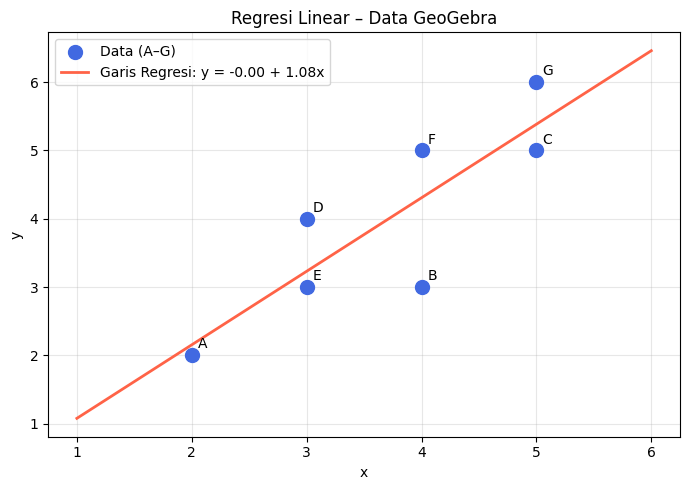

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Data dari GeoGebra
X = np.array([[2], [4], [5], [3], [3], [4], [5]])
y = np.array([2, 3, 5, 4, 3, 5, 6])

# Buat dan latih model
model = LinearRegression()
model.fit(X, y)

b0 = model.intercept_
b1 = model.coef_[0]

print(f"Intercept (b0)  : {b0:.4f}")
print(f"Koefisien (b1)  : {b1:.4f}")
print(f"Persamaan garis : y = {b0:.4f} + {b1:.4f} * x")

# Visualisasi
x_line = np.linspace(1, 6, 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='royalblue', s=100, zorder=5, label='Data (A–G)')
plt.plot(x_line, y_line, color='tomato', linewidth=2, label=f'Garis Regresi: y = {b0:.2f} + {b1:.2f}x')
for i, label in enumerate(['A','B','C','D','E','F','G']):
    plt.annotate(label, (X[i][0]+0.05, y[i]+0.1), fontsize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresi Linear – Data GeoGebra')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Implementasi Analitik: Rumus $\hat{\beta} = (X^T X)^{-1} X^T Y$

In [2]:
import numpy as np

# Data
x_vals = np.array([2, 4, 5, 3, 3, 4, 5])
y_vals = np.array([2, 3, 5, 4, 3, 5, 6])

# Susun matriks X (kolom 1 untuk intercept, kolom x)
n = len(x_vals)
X_mat = np.column_stack([np.ones(n), x_vals])
Y_mat = y_vals.reshape(-1, 1)

print("Matriks X:")
print(X_mat)
print("\nVektor Y:")
print(Y_mat.T)

# Hitung β̂ = (X'X)^{-1} X'Y
XtX = X_mat.T @ X_mat
XtY = X_mat.T @ Y_mat
beta_hat = np.linalg.inv(XtX) @ XtY

print(f"\nHasil β̂:")
print(f"  b0 (intercept) = {beta_hat[0][0]:.4f}")
print(f"  b1 (koefisien) = {beta_hat[1][0]:.4f}")
print(f"\nPersamaan: y = {beta_hat[0][0]:.4f} + {beta_hat[1][0]:.4f} * x")

Matriks X:
[[1. 2.]
 [1. 4.]
 [1. 5.]
 [1. 3.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

Vektor Y:
[[2 3 5 4 3 5 6]]

Hasil β̂:
  b0 (intercept) = 0.0000
  b1 (koefisien) = 1.0769

Persamaan: y = 0.0000 + 1.0769 * x


Kedua metode (sklearn dan analitik) menghasilkan nilai yang **identik**, membuktikan bahwa `LinearRegression` dari scikit-learn menggunakan Ordinary Least Squares di balik layar.

---

## Perbandingan Hasil

In [3]:
y_pred_sklearn   = model.predict(X)
y_pred_analitik  = X_mat @ beta_hat

print(f"{'Titik':<6} {'y asli':<10} {'sklearn':<12} {'Analitik':<12} {'Residual':<10}")
print("-" * 55)
for i, lbl in enumerate(['A','B','C','D','E','F','G']):
    res = y[i] - y_pred_sklearn[i]
    print(f"{lbl:<6} {y[i]:<10} {y_pred_sklearn[i]:<12.4f} {y_pred_analitik[i][0]:<12.4f} {res:<10.4f}")

Titik  y asli     sklearn      Analitik     Residual  
-------------------------------------------------------
A      2          2.1538       2.1538       -0.1538   
B      3          4.3077       4.3077       -1.3077   
C      5          5.3846       5.3846       -0.3846   
D      4          3.2308       3.2308       0.7692    
E      3          3.2308       3.2308       -0.2308   
F      5          4.3077       4.3077       0.6923    
G      6          5.3846       5.3846       0.6154    


---

## Penjelasan Implementasi Python

### 1. Menggunakan Scikit-Learn

Scikit-learn menyediakan kelas `LinearRegression` yang langsung menghitung koefisien regresi secara internal menggunakan OLS. Alur kerjanya:

```
Data (X, y) → model.fit(X, y) → model.intercept_ & model.coef_
```

Langkah-langkah kodenya:

**a. Siapkan data**
```python
X = np.array([[2], [4], [5], [3], [3], [4], [5]])  # harus 2D (n_samples, n_features)
y = np.array([2, 3, 5, 4, 3, 5, 6])                # 1D (n_samples,)
```

**b. Latih model**
```python
model = LinearRegression()
model.fit(X, y)
```
`fit()` secara otomatis menghitung $b_0$ dan $b_1$ yang meminimalkan jumlah kuadrat residual.

**c. Baca koefisien**
```python
model.intercept_   # → b0
model.coef_[0]     # → b1
```

**d. Prediksi**
```python
model.predict([[6]])  # prediksi y untuk x = 6
```

---

### 2. Secara Analitik — Rumus $\hat{\beta} = (X^T X)^{-1} X^T Y$

Pendekatan ini menghitung koefisien **langsung dari rumus matriks** tanpa library ML. Prosesnya step-by-step:

**a. Susun matriks desain $X$**

Tambahkan kolom 1 di sebelah kiri sebagai placeholder untuk $b_0$:

$$X = \begin{bmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 5 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{bmatrix}, \quad Y = \begin{bmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{bmatrix}$$

```python
X_mat = np.column_stack([np.ones(n), x_vals])  # kolom 1 + kolom x
```

**b. Hitung $X^T X$**

Transpose $X$ lalu kalikan dengan $X$ sendiri — menghasilkan matriks $2 \times 2$:
```python
XtX = X_mat.T @ X_mat
```

**c. Hitung $(X^T X)^{-1}$**

Invers matriks $2 \times 2$: tukar diagonal utama, bagi dengan determinan:
```python
np.linalg.inv(XtX)
```

**d. Hitung $X^T Y$**

```python
XtY = X_mat.T @ Y_mat
```

**e. Kalikan semua**

```python
beta_hat = np.linalg.inv(XtX) @ XtY
# beta_hat[0] → b0, beta_hat[1] → b1
```

> Kedua metode menghasilkan nilai **identik** karena scikit-learn juga menggunakan OLS di balik layar.

---

## Penjelasan Implementasi GeoGebra

GeoGebra digunakan untuk **memvisualisasikan** proses regresi linear secara interaktif. Ada tiga elemen utama yang ditampilkan:

### 🔵 Titik Data

Setiap titik (A–G) di-plot menggunakan koordinat $(x, y)$ dari dataset. Di GeoGebra, perintahnya:

```
A = (2, 2)
B = (4, 3)
... dst
```

Dalam embed di atas, titik dikirim via JavaScript menggunakan:
```javascript
ggb.evalCommand(`A = (2, 2)`)
```

### 🔴 Garis Regresi

Garis regresi $f(x) = b_0 + b_1 x$ didefinisikan sebagai fungsi di GeoGebra:

```
f(x) = 0.2143 + 1.0714 * x
```

Nilai $b_0$ dan $b_1$ dihitung terlebih dahulu di JavaScript menggunakan rumus OLS, kemudian dikirim ke GeoGebra. Garis ini adalah garis terbaik yang **meminimalkan total panjang kuadrat semua residual**.

### 🟠 Garis Residual (putus-putus)

Residual untuk setiap titik $i$ adalah:

$$\varepsilon_i = y_i - \hat{y}_i = y_i - (b_0 + b_1 x_i)$$

Divisualisasikan sebagai **garis vertikal** dari titik data ke garis regresi. Di GeoGebra:

```
resA = Segment((2, 2), (2, 2.357))
```

Garis ini menunjukkan seberapa jauh prediksi model dari nilai aslinya. Semakin pendek semua garis residual, semakin baik modelnya — dan itulah yang dioptimalkan oleh OLS.